# IDR Prediction — Baseline Training
Transformer-LSTM on `prot_bert_bfd` embeddings. Evaluated on CAID (652 sequences).

**Run all cells top to bottom. Loss and metrics update in real time.**

In [11]:
# ── 1. Environment setup (Colab only — skip if running locally) ──────────────
import sys, os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !git clone https://github.com/siavashprh/idr-prediction.git
    os.chdir('idr-prediction')
    !pip install -q -e .
    !pip install -q 'transformers==5.7.0' 'tokenizers==0.22.2' biopython omegaconf sentencepiece safetensors
    # Upgrade torch if needed (Colab default may be < 2.6)
    import torch
    if tuple(int(x) for x in torch.__version__.split('.')[:2]) < (2, 6):
        !pip install -q 'torch>=2.6.0'

print('Working dir:', os.getcwd())

Cloning into 'idr-prediction'...
remote: Enumerating objects: 186, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 186 (delta 5), reused 29 (delta 5), pack-reused 149 (from 2)
Receiving objects: 100% (186/186), 73.15 MiB | 20.03 MiB/s, done.
Resolving deltas: 100% (6/6), done.
  Preparing metadata (setup.py) ... done
Working dir: /content/idr-prediction/idr-prediction


In [12]:
# ── 2. Imports ───────────────────────────────────────────────────────────────
import random
import time
from IPython.display import clear_output

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import transformers
from tqdm.notebook import tqdm
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

transformers.logging.set_verbosity_error()

from src.config import ModelConfig, OptimizerConfig
from src.data.data import IDPData, get_caid_data, get_disprot_cut_data
from src.models.sequence_models import TransformerLSTMModel

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [13]:
# ── 3. Config ────────────────────────────────────────────────────────────────
CFG = dict(
    # Model
    pre_model    = 'Rostlab/prot_bert_bfd',
    input_dim    = 1024,
    hidden_dim   = 64,
    num_heads    = 4,
    num_blocks   = 2,
    dropout      = 0.6,
    with_lstm    = True,
    lstm_layers  = 2,
    # Training
    lr                = 3e-4,
    batch_size        = 64,   # reduce to 16 if on a 4GB GPU
    n_epoch           = 10,
    first_class_weight= 0.1,
)
print(CFG)

{'pre_model': 'Rostlab/prot_bert_bfd', 'input_dim': 1024, 'hidden_dim': 64, 'num_heads': 4, 'num_blocks': 2, 'dropout': 0.6, 'with_lstm': True, 'lstm_layers': 2, 'lr': 0.0003, 'batch_size': 64, 'n_epoch': 10, 'first_class_weight': 0.1}


In [14]:
# ── 4. Data ──────────────────────────────────────────────────────────────────
print('Loading training data...')
cut = get_disprot_cut_data()
train_data = IDPData(cut['sequences'], cut['disorder region'])
print(f'  Training chunks : {len(train_data.X)}')

print('Loading CAID data...')
caid = get_caid_data()
print(f'  CAID sequences  : {len(caid["sequences"])}')
total = sum(len(s) for s in caid['sequences'])
disord = sum(v for labels in caid['disorder region'] for v in labels)
print(f'  CAID residues   : {total:,}  ({100*disord/total:.1f}% disordered)')

Loading training data...
  Training chunks : 2107
Loading CAID data...
  CAID sequences  : 652
  CAID residues   : 338,068  (16.2% disordered)


In [15]:
# ── 5. Model ─────────────────────────────────────────────────────────────────
print('Loading prot_bert_bfd (downloads ~1.6 GB on first run)...')
model_config = ModelConfig()
model_config.model_name = 'baseline_transformer_lstm'

model = TransformerLSTMModel(
    pre_model_name   = CFG['pre_model'],
    device           = device,
    input_dim        = CFG['input_dim'],
    linear_hidden_dim= CFG['hidden_dim'],
    num_heads        = CFG['num_heads'],
    num_blocks       = CFG['num_blocks'],
    dropout          = CFG['dropout'],
    model_config     = model_config,
    with_lstm        = CFG['with_lstm'],
    lstm_n_layers    = CFG['lstm_layers'],
)
print('Model ready.')

Loading prot_bert_bfd (downloads ~1.6 GB on first run)...


Loading weights:   0%|          | 0/487 [00:00<?, ?it/s]

Model ready.


Epoch 10: mean_loss=0.3221  (12.1 min elapsed)


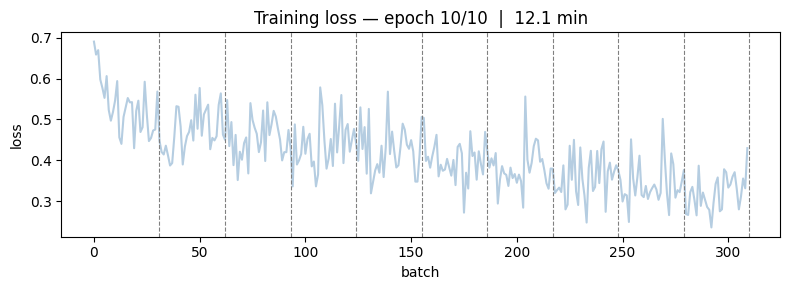


Training complete in 12.1 min


In [16]:
# ── 6. Training loop (with live loss plot) ───────────────────────────────────
loss_fn = nn.CrossEntropyLoss(
    ignore_index=2,
    weight=torch.tensor([CFG['first_class_weight'], 1 - CFG['first_class_weight']]).to(device),
)
optimizer = torch.optim.Adam(model.model.parameters(), lr=CFG['lr'])

batch_size  = CFG['batch_size']
n_epoch     = CFG['n_epoch']
n           = len(train_data.X)
round_size  = n - (n % batch_size) - batch_size

epoch_losses = []
all_batch_losses = []

t_start = time.time()

for epoch in range(n_epoch):
    model.model.train()
    shuffle = list(range(n))
    random.shuffle(shuffle)

    batch_losses = []
    pbar = tqdm(range(0, round_size, batch_size),
                desc=f'Epoch {epoch+1}/{n_epoch}', leave=True)

    for j in pbar:
        indices = shuffle[j : j + batch_size]
        X = [train_data.X[i] for i in indices]
        max_len = max(len(s) for s in X)

        y = torch.full((batch_size, max_len), 2).long().to(device)
        for k, i in enumerate(indices):
            reg = train_data.y[i]
            y[k, :len(reg)] = torch.tensor(reg, dtype=torch.long)

        pred = model.model(X)
        loss = loss_fn(pred.reshape(-1, 2), y.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())
        all_batch_losses.append(loss.item())
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'avg': f'{np.mean(batch_losses):.4f}'})

    epoch_mean = np.mean(batch_losses)
    epoch_losses.append(epoch_mean)
    elapsed = (time.time() - t_start) / 60

    # clear first so the epoch summary and plot are the only output visible
    clear_output(wait=True)
    print(f'Epoch {epoch+1}: mean_loss={epoch_mean:.4f}  ({elapsed:.1f} min elapsed)')

    steps_per_epoch = round_size // batch_size
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(all_batch_losses, alpha=0.4, color='steelblue', label='batch loss')
    for e in range(1, epoch + 2):
        ax.axvline(e * steps_per_epoch, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('batch'); ax.set_ylabel('loss')
    ax.set_title(f'Training loss — epoch {epoch+1}/{n_epoch}  |  {elapsed:.1f} min')
    plt.tight_layout(); plt.show(); plt.close()

print(f'\nTraining complete in {(time.time()-t_start)/60:.1f} min')

In [17]:
# ── 7. Save checkpoint ───────────────────────────────────────────────────────
import os
os.makedirs('data_repository/ckpt', exist_ok=True)
ckpt_path = 'data_repository/ckpt/baseline_transformer_lstm.pth'
torch.save(model.model.state_dict(), ckpt_path)
print(f'Checkpoint saved: {ckpt_path}')

if IN_COLAB:
    from google.colab import files
    files.download(ckpt_path)
    print('Browser download triggered.')

Checkpoint saved: data_repository/ckpt/baseline_transformer_lstm.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Browser download triggered.


In [18]:
# ── 8. CAID evaluation ───────────────────────────────────────────────────────
def predict_proba_sequence(model, sequence, max_length=400, alpha=0.75):
    if len(sequence) <= max_length:
        p = model.predict_proba([sequence])
        return np.array(p if isinstance(p, list) else [p])
    y = np.zeros(len(sequence))
    weight = np.zeros(len(sequence))
    start = 0
    while start < len(sequence):
        end = min(start + max_length, len(sequence))
        p = model.predict_proba([sequence[start:end]])
        chunk = np.array(p if isinstance(p, list) else [p])
        y[start:end] += chunk
        weight[start:end] += 1.0
        if end == len(sequence): break
        start += int(max_length * alpha)
    return y / np.maximum(weight, 1.0)

model.model.eval()
all_true, all_pred, all_proba = [], [], []

for seq, labels in tqdm(zip(caid['sequences'], caid['disorder region']),
                        total=len(caid['sequences']), desc='CAID eval'):
    with torch.no_grad():
        proba = predict_proba_sequence(model, list(seq))
    pred = (proba >= 0.5).astype(int)
    all_true.extend(labels)
    all_pred.extend(pred.tolist())
    all_proba.extend(proba.tolist())

all_true = np.array(all_true)
all_pred = np.array(all_pred)
all_proba = np.array(all_proba)

metrics = {
    'F1 (macro)' : f1_score(all_true, all_pred, average='macro', zero_division=1),
    'Precision'  : precision_score(all_true, all_pred, average='macro', zero_division=1),
    'Recall'     : recall_score(all_true, all_pred, average='macro', zero_division=1),
    'AUC-ROC'    : roc_auc_score(all_true, all_proba),
}

print('\n── CAID Results ──────────────────────────')
for k, v in metrics.items():
    print(f'  {k:<14} {v:.4f}')
print(f'\n  Target F1: ~0.618  (thesis baseline)')

CAID eval:   0%|          | 0/652 [00:00<?, ?it/s]


── CAID Results ──────────────────────────
  F1 (macro)     0.5838
  Precision      0.6087
  Recall         0.6963
  AUC-ROC        0.7381

  Target F1: ~0.618  (thesis baseline)


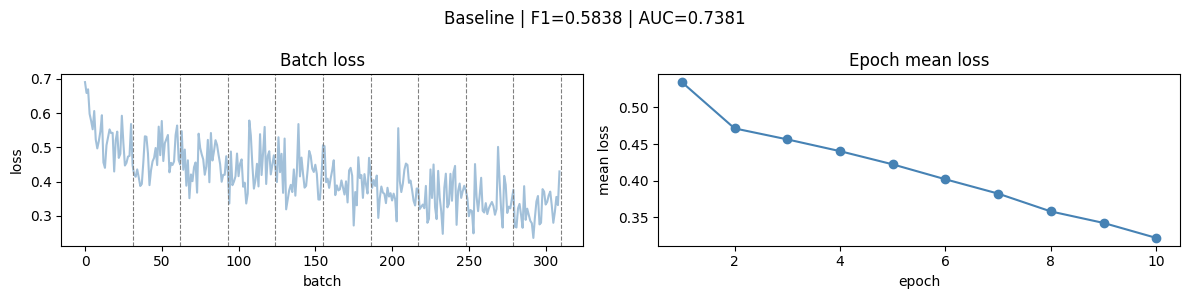

In [19]:
# ── 9. Loss curve (final) ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].plot(all_batch_losses, alpha=0.5, color='steelblue')
steps_per_epoch = round_size // batch_size
for e in range(1, n_epoch + 1):
    axes[0].axvline(e * steps_per_epoch, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('batch'); axes[0].set_ylabel('loss')
axes[0].set_title('Batch loss')

axes[1].plot(range(1, len(epoch_losses)+1), epoch_losses, 'o-', color='steelblue')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('mean loss')
axes[1].set_title('Epoch mean loss')

plt.suptitle(f'Baseline | F1={metrics["F1 (macro)"]:.4f} | AUC={metrics["AUC-ROC"]:.4f}')
plt.tight_layout(); plt.show()

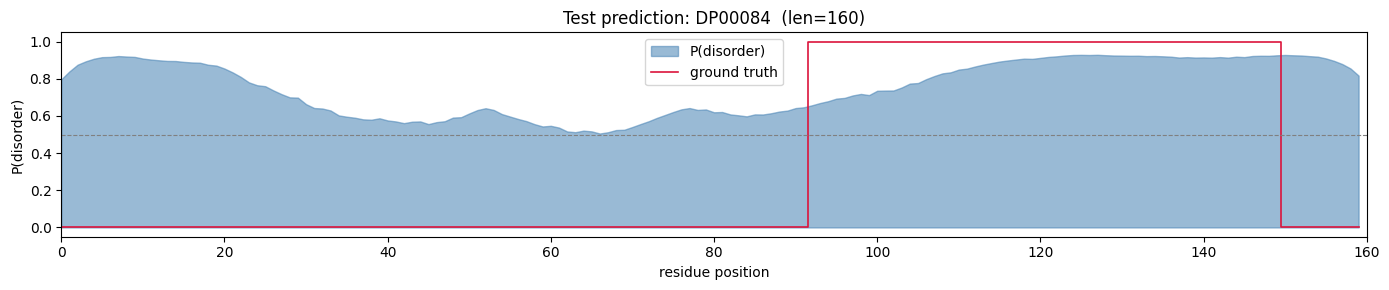

Sequence F1 (macro): 0.2661
Predicted disordered: 160 / 160 residues (100.0%)
True disordered:      58 / 160 residues (36.2%)


In [20]:
# ── 10. Test prediction on a single sequence ─────────────────────────────────
# Runs on the first CAID sequence and plots predicted vs true disorder.
# To test a custom sequence, replace seq / true_labels / seq_id below.
idx = 0
seq      = caid['sequences'][idx]
true_labels = caid['disorder region'][idx]
seq_id   = caid['id'][idx]

model.model.eval()
with torch.no_grad():
    proba = predict_proba_sequence(model, list(seq))

pred = (proba >= 0.5).astype(int)
residues = range(len(seq))

fig, ax = plt.subplots(figsize=(14, 3))
ax.fill_between(residues, proba, alpha=0.55, color='steelblue', label='P(disorder)')
ax.step(residues, true_labels, where='mid', color='crimson', linewidth=1.2, label='ground truth')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlim(0, len(seq))
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('residue position')
ax.set_ylabel('P(disorder)')
ax.set_title(f'Test prediction: {seq_id}  (len={len(seq)})')
ax.legend()
plt.tight_layout(); plt.show(); plt.close()

from sklearn.metrics import f1_score as _f1
f1 = _f1(true_labels, pred.tolist(), average='macro', zero_division=1)
print(f'Sequence F1 (macro): {f1:.4f}')
print(f'Predicted disordered: {int(pred.sum())} / {len(pred)} residues ({100*pred.mean():.1f}%)')
print(f'True disordered:      {sum(true_labels)} / {len(true_labels)} residues ({100*sum(true_labels)/len(true_labels):.1f}%)')